In [36]:
import pandas as pd
import re
import nltk
import numpy as np

In [16]:
df = pd.read_csv('train.csv')

# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

df.shape

(24783, 6)

In [17]:
df.head

<bound method NDFrame.head of        count  hate_speech_count  offensive_language_count  neither_count  \
0          3                  0                         0              3   
1          3                  0                         3              0   
2          3                  0                         3              0   
3          3                  0                         2              1   
4          6                  0                         6              0   
...      ...                ...                       ...            ...   
24778      3                  0                         2              1   
24779      3                  0                         1              2   
24780      3                  0                         3              0   
24781      6                  0                         6              0   
24782      3                  0                         0              3   

       class                                             

In [18]:
def remove_duplicate_rows(df):
    # Check for duplicate rows
    duplicate_rows = df[df.duplicated()]

    # Display duplicate rows
    print("Duplicate Rows:")
    print(duplicate_rows)

    # Drop duplicate rows (in-place)
    df.drop_duplicates(inplace=True)

    # Return the DataFrame after removing duplicates
    return df


df = remove_duplicate_rows(df)
print("DataFrame shape after removing duplicates:", df.shape)


Duplicate Rows:
Empty DataFrame
Columns: [count, hate_speech_count, offensive_language_count, neither_count, class, tweet]
Index: []
DataFrame shape after removing duplicates: (24783, 6)


In [19]:
df.describe()

,count,hate_speech_count,offensive_language_count,neither_count,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,3.243473,0.280515,2.413711,0.549247,1.110277
std,0.883060,0.631851,1.399459,1.113299,0.462089
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000,0.000000,1.000000
50%,3.000000,0.000000,3.000000,0.000000,1.000000
75%,3.000000,0.000000,3.000000,0.000000,1.000000
max,9.000000,7.000000,9.000000,9.000000,2.000000


In [20]:
df.dtypes

count                        int64
hate_speech_count            int64
offensive_language_count     int64
neither_count                int64
class                        int64
tweet                       object
dtype: object

In [21]:
# Check for missing values
print(df.isnull().sum())

count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
dtype: int64


In [22]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [23]:
# dataset shape to know how many tweets in the datasets
print(f"num of tweets: {df.shape}")

# extract the text and labels
tweet = list(df['tweet'])
labels = list(df['class'])


num of tweets: (24783, 6)


In [24]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


# Assuming your dataframe is named df
# Assuming your dataframe is named df
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = re.sub(r'^[^a-zA-Z]+|[^a-zA-Z]+$', '', text) # Remove leading and trailing non-alphabetic characters
    #text = text.lower()  # Convert to lowercase
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]  # Remove stop words and apply stemming
    return ' '.join(words)



In [25]:
# Create a new column 'cleaned_tweet' with the cleaned text
df['cleaned_tweet'] = df['tweet'].apply(clean_text)

# Optionally, drop the original 'tweet' column if you no longer need it
df.drop(columns=['tweet'], inplace=True)

# Display the updated DataFrame
print(df.head())

   count  hate_speech_count  offensive_language_count  neither_count  class  \
0      3                  0                         0              3      2   
1      3                  0                         3              0      1   
2      3                  0                         3              0      1   
3      3                  0                         2              1      1   
4      6                  0                         6              0      1   

                                       cleaned_tweet  
0  rt @mayasolovely: as woman complain clean hous...  
1  rt @mleew17: boy dat cold...tyga dwn bad cuffi...  
2  rt @urkindofbrand dawg!!!! rt @80sbaby4life: y...  
3       rt @c_g_anderson: @viva_bas look like tranni  
4  rt @shenikaroberts: the shit hear might true m...  


In [26]:
df.loc[200]

count                                                                       3
hate_speech_count                                                           1
offensive_language_count                                                    2
neither_count                                                               0
class                                                                       1
cleaned_tweet               newsomejade: i ain't never seen bitch obsess n...
Name: 200, dtype: object

In [27]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Assuming your dataframe is named df
nltk.download('vader_lexicon')  # Download the VADER lexicon for sentiment analysis
sid = SentimentIntensityAnalyzer()

# Apply sentiment analysis to the 'tweet' column
df['sentiment_score'] = df['cleaned_tweet'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Define a function to categorize sentiment based on the compound score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment categorization to create a new column 'sentiment'
df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

# Display the DataFrame with sentiment analysis results
print(df[['cleaned_tweet', 'sentiment_score', 'sentiment']].head())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lakhey\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                       cleaned_tweet  sentiment_score  \
0  rt @mayasolovely: as woman complain clean hous...           0.0516   
1  rt @mleew17: boy dat cold...tyga dwn bad cuffi...          -0.5423   
2  rt @urkindofbrand dawg!!!! rt @80sbaby4life: y...          -0.9448   
3       rt @c_g_anderson: @viva_bas look like tranni           0.3612   
4  rt @shenikaroberts: the shit hear might true m...           0.4588   

  sentiment  
0  Positive  
1  Negative  
2  Negative  
3  Positive  
4  Positive  


In [29]:
import re
import nltk
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('vader_lexicon')

def extract_additional_features(df, hate_speech_terms=None):
    # Extract sentiment scores
    sid = SentimentIntensityAnalyzer()
    df['sentiment_score'] = df['cleaned_tweet'].apply(lambda x: sid.polarity_scores(x)['compound'])

    # Extract n-gram frequencies
    vectorizer = CountVectorizer(ngram_range=(1, 2))
    ngram_features = vectorizer.fit_transform(df['cleaned_tweet'])

    # Presence of Hate Speech Terms
    if hate_speech_terms:
        for term in hate_speech_terms:
            df[f'contains_{term}'] = df['cleaned_tweet'].apply(lambda x: 1 if term in x else 0)

    # Linguistic Markers (Example: Offensive language)
    df['contains_offensive'] = df['cleaned_tweet'].apply(lambda x: 1 if 'offensive_word' in x else 0)

    # Character-Level Features
    df['contains_excessive_punctuation'] = df['cleaned_tweet'].apply(lambda x: 1 if '!!' in x else 0)
    df['contains_uppercase'] = df['cleaned_tweet'].apply(lambda x: 1 if any(char.isupper() for char in x) else 0)

    # Emoticon and Emoji Analysis
    df['contains_emoticon'] = df['cleaned_tweet'].apply(lambda x: 1 if '😠' in x else 0)

    # Optionally, drop the original 'tweet' column if you no longer need it
    #df.drop(columns=['tweet'], inplace=True)

    return df, ngram_features


# Example usage:
hate_speech_terms = [
    'allah akbar', 'blacks', 'chink', 'chinks', 'dykes',
    'faggot', 'faggots', 'fags', 'homo', 'inbred',
    'nigger', 'niggers', 'queers', 'raped', 'savages',
    'slave', 'spic', 'wetback', 'wetbacks', 'whites',
    'a dirty', 'a nigger', 'all niggers', 'all white',
    'always fuck', 'ass white', 'be killed', 'beat him',
    'biggest faggot', 'blame the', 'butt ugly', 'chink eyed',
    'chinks in', 'coon shit', 'dumb monkey', 'dumb nigger',
    'fag and', 'fag but', 'faggot a', 'faggot and', 'faggot ass',
    'faggot bitch', 'faggot for', 'faggot smh', 'faggot that',
    'faggots and', 'faggots like', 'faggots usually', 'faggots who',
    'fags are', 'fuckin faggot', 'fucking faggot', 'fucking gay',
    'fucking hate', 'fucking nigger', 'fucking queer', 'gay ass',
    'get raped', 'hate all', 'hate faggots', 'hate fat', 'hate you',
    'here faggot', 'is white', 'jungle bunny', 'kill all',
    'kill yourself', 'little faggot', 'many niggers', 'married to',
    'me faggot', 'my coon', 'nigga ask', 'niggas like', 'nigger ass',
    'nigger is', 'nigger music', 'niggers are', 'of fags', 'of white',
    'raped and', 'raped by', 'sand nigger', 'savages that',
    'shorty bitch', 'spear chucker', 'spic cop', 'stupid nigger',
    'that fag', 'that faggot', 'that nigger', 'the faggots',
    'the female', 'the niggers', 'their heads', 'them white',
    'then faggot', 'this nigger', 'to rape', 'trailer park',
    'trash with', 'u fuckin', 'ugly dyke', 'up nigger', 'white ass',
    'white boy', 'white person', 'white trash', 'with niggas',
    'you fag', 'you nigger', 'you niggers', 'your faggot',
    'your nigger', 'a bitch made', 'a fag and', 'a fag but',
    'a faggot and', 'a faggot for', 'a fucking queer', 'a nigga ask',
    'a white person', 'a white trash', 'all these fucking', 'are all white',
    'be killed for', 'bitch made nigga', 'faggots like you',
    'faggots usually have', 'fuck outta here', 'fuck u talking',
    'fuck you too', 'fucking hate you', 'full of white', 'him a nigga',
    'his shorty bitch', 'how many niggers', 'is a fag', 'is a faggot',
    'is a fuckin', 'is a fucking', 'is a nigger', 'like a faggot',
    'like da colored', 'many niggers are', 'nigga and his', 'niggers are in',
    'of white trash', 'shut up nigger', 'still a faggot', 'the biggest faggot',
    'the faggots who', 'the fuck do', 'they all look', 'what a fag',
    'white bitch in', 'white trash and', 'you a fag', 'you a lame',
    'you a nigger', 'you fuck wit', 'you fucking faggot', 'your a cunt',
    'your a dirty', 'your bitch in', 'a bitch made nigga', 'a lame nigga you',
    'faggot if you ever', 'full of white trash', 'how many niggers are',
    'is full of white', 'lame nigga you a', 'many niggers are in',
    'nigga you a lame', 'niggers are in my', 'wit a lame nigga',
    'you a lame bitch', 'you fuck wit a'
]

df_processed, ngram_features = extract_additional_features(df, hate_speech_terms)

df.head

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lakhey\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


<bound method NDFrame.head of        count  hate_speech_count  offensive_language_count  neither_count  \
0          3                  0                         0              3   
1          3                  0                         3              0   
2          3                  0                         3              0   
3          3                  0                         2              1   
4          6                  0                         6              0   
...      ...                ...                       ...            ...   
24778      3                  0                         2              1   
24779      3                  0                         1              2   
24780      3                  0                         3              0   
24781      6                  0                         6              0   
24782      3                  0                         0              3   

       class                                      cleaned

In [31]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
# Assuming your dataframe is named df
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# Create a new column 'lemmatized_tweet' with the lemmatized text
df['lemmatized_tweet'] = df['cleaned_tweet'].apply(lemmatize_text)

# Display the updated DataFrame
print(df[['cleaned_tweet', 'lemmatized_tweet', 'sentiment_score', 'sentiment']].head())


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lakhey\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                       cleaned_tweet  \
0  rt @mayasolovely: as woman complain clean hous...   
1  rt @mleew17: boy dat cold...tyga dwn bad cuffi...   
2  rt @urkindofbrand dawg!!!! rt @80sbaby4life: y...   
3       rt @c_g_anderson: @viva_bas look like tranni   
4  rt @shenikaroberts: the shit hear might true m...   

                                    lemmatized_tweet  sentiment_score  \
0  rt @mayasolovely: a woman complain clean house...           0.0516   
1  rt @mleew17: boy dat cold...tyga dwn bad cuffi...          -0.5423   
2  rt @urkindofbrand dawg!!!! rt @80sbaby4life: y...          -0.9448   
3       rt @c_g_anderson: @viva_bas look like tranni           0.3612   
4  rt @shenikaroberts: the shit hear might true m...           0.4588   

  sentiment  
0  Positive  
1  Negative  
2  Negative  
3  Positive  
4  Positive  


C:\Users\Lakhey\AppData\Local\Temp\ipykernel_19032\914830795.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['lemmatized_tweet'] = df['cleaned_tweet'].apply(lemmatize_text)


In [ ]:
!pip install matplotlib

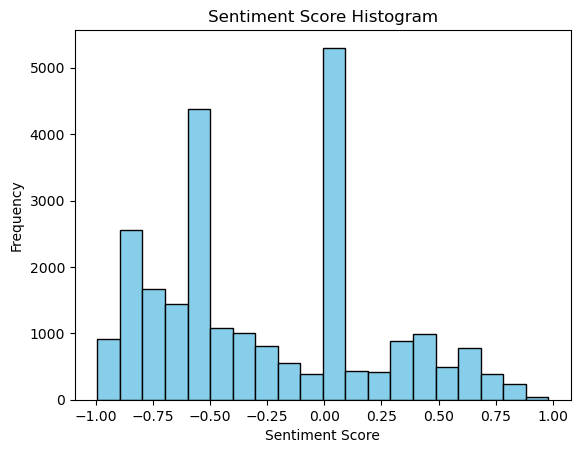

In [32]:
import matplotlib.pyplot as plt

# Plot histogram of sentiment scores
plt.hist(df['sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Sentiment Score Histogram')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()


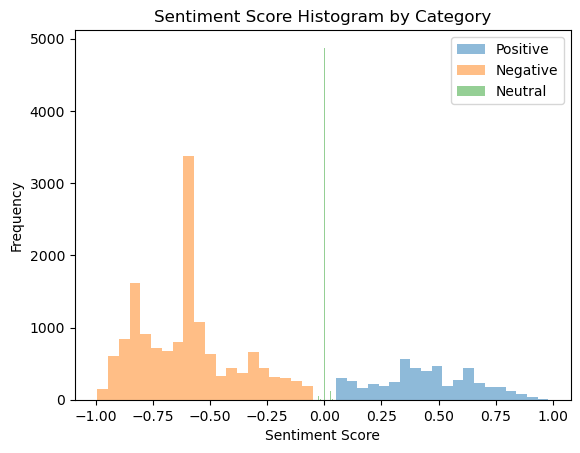

In [33]:
# Plot histograms for each sentiment category
for sentiment_category in ['Positive', 'Negative', 'Neutral']:
    subset = df[df['sentiment'] == sentiment_category]
    plt.hist(subset['sentiment_score'], bins=20, label=sentiment_category, alpha=0.5)

plt.title('Sentiment Score Histogram by Category')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()


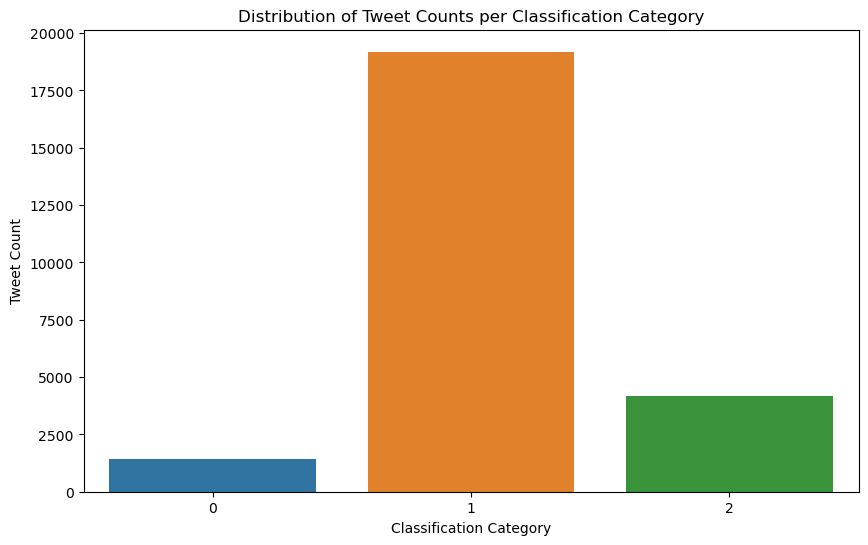

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of tweet counts per classification category
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=df)
plt.title('Distribution of Tweet Counts per Classification Category')
plt.xlabel('Classification Category')
plt.ylabel('Tweet Count')
plt.show()


In [40]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from scipy.sparse import hstack, csr_matrix


# Tokenize the text data
max_words = 5000  # Set an appropriate vocabulary size
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['lemmatized_tweet'])
sequences = tokenizer.texts_to_sequences(df['lemmatized_tweet'])

# Pad sequences to have a consistent length
max_sequence_length = 100  # You can adjust this based on your data and requirements
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length)

# Additional features
sentiment_scores = np.array(df['sentiment_score']).reshape(-1, 1)
ngram_features_sparse = csr_matrix(ngram_features)  # Convert ngram_features to a sparse matrix
hate_speech_features = df[['contains_' + term for term in hate_speech_terms]].values
linguistic_markers = df[['contains_offensive', 'contains_excessive_punctuation', 'contains_uppercase']].values
emoticon_features = np.array(df['contains_emoticon']).reshape(-1, 1)

# Combine text and additional features
combined_features = hstack([padded_sequences, sentiment_scores, ngram_features_sparse, hate_speech_features, linguistic_markers, emoticon_features])


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_features, df['class'], test_size=0.2, random_state=42)

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predictions on the test set
rf_predictions = rf_classifier.predict(X_test)

# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'Random Forest Accuracy: {rf_accuracy}')

# Extra Trees Classifier
et_classifier = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_classifier.fit(X_train, y_train)

# Predictions on the test set
et_predictions = et_classifier.predict(X_test)

# Evaluate Extra Trees model
et_accuracy = accuracy_score(y_test, et_predictions)
print(f'Extra Trees Accuracy: {et_accuracy}') 


Random Forest Accuracy: 0.8408311478716965
Extra Trees Accuracy: 0.8444623764373613


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_features, df['class'], test_size=0.2, random_state=42)

# Define empty lists to store training history
rf_train_accuracies = []
rf_test_accuracies = []
et_train_accuracies = []
et_test_accuracies = []

# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Track training and testing accuracy during each iteration
for i in range(100): # Replace 100 with your desired number of training epochs
    rf_classifier.fit(X_train[:i * len(X_train) // 100], y_train[:i * len(y_train) // 100])
    rf_train_accuracies.append(accuracy_score(y_train[i * len(y_train) // 100:], rf_classifier.predict(X_train[i * len(X_train) // 100:])))
    rf_test_accuracies.append(accuracy_score(y_test, rf_classifier.predict(X_test)))

# Predictions on the test set
rf_predictions = rf_classifier.predict(X_test)

# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f'Random Forest Accuracy: {rf_accuracy}')

# Extra Trees Classifier
et_classifier = ExtraTreesClassifier(n_estimators=100, random_state=42)

# Track training and testing accuracy during each iteration
for i in range(100):
    et_classifier.fit(X_train[:i * len(X_train) // 100], y_train[:i * len(y_train) // 100])
    et_train_accuracies.append(accuracy_score(y_train[i * len(y_train) // 100:], et_classifier.predict(X_train[i * len(X_train) // 100:])))
    et_test_accuracies.append(accuracy_score(y_test, et_classifier.predict(X_test)))

# Predictions on the test set
et_predictions = et_classifier.predict(X_test)

# Evaluate Extra Trees model
et_accuracy = accuracy_score(y_test, et_predictions)
print(f'Extra Trees Accuracy: {et_accuracy}')

# Plot training and testing accuracy for both models
plt.plot(range(100), rf_train_accuracies, label='RF Train Accuracy')
plt.plot(range(100), rf_test_accuracies, label='RF Test Accuracy')
plt.plot(range(100), et_train_accuracies, label='ET Train Accuracy')
plt.plot(range(100), et_test_accuracies, label='ET Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Flatten, concatenate
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.sparse import hstack, csr_matrix
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# Assuming you have df, combined_features, and hate_speech_terms as defined before

# Tokenize the text data
max_words = 5000  # Set an appropriate vocabulary size
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['lemmatized_tweet'])
sequences = tokenizer.texts_to_sequences(df['lemmatized_tweet'])

# Pad sequences to have a consistent length
max_sequence_length = 100  # You can adjust this based on your data and requirements
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length)

# Additional features
sentiment_scores = np.array(df['sentiment_score']).reshape(-1, 1)
ngram_features_sparse = csr_matrix(ngram_features)  # Convert ngram_features to a sparse matrix
hate_speech_features = df[['contains_' + term for term in hate_speech_terms]].values
linguistic_markers = df[['contains_offensive', 'contains_excessive_punctuation', 'contains_uppercase']].values
emoticon_features = np.array(df['contains_emoticon']).reshape(-1, 1)

# Combine text and additional features
combined_features = hstack([padded_sequences, sentiment_scores, ngram_features_sparse, hate_speech_features, linguistic_markers, emoticon_features])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_features, df['class'], test_size=0.2, random_state=42)

# Build the neural network model
embedding_dim = 50  # You can adjust this based on your data and requirements

model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=embedding_dim, input_length=max_sequence_length))
model.add(LSTM(units=100))
model.add(Dense(units=1, activation='sigmoid'))

# Flatten the output of the embedding layer
model.add(Flatten())

# Concatenate the flattened embedding layer output with the additional features
model.add(concatenate([model.layers[-1].output, X_train]))

# Add more Dense layers as needed
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model on the training set
model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Now you can use the trained model for predictions
